## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from paths import PROCESSED_DIR

## Load the data file

In [3]:
FILE_PATH = PROCESSED_DIR / 'final_features.csv' 
if not FILE_PATH.exists():
    raise FileNotFoundError('Could not find final_features.csv')

df = pd.read_csv(FILE_PATH)
print('Loaded:', FILE_PATH)
print('Shape:', df.shape)
df.head()

Loaded: ..\resources\data\processed\final_features.csv
Shape: (126530, 8)


,user_id,product_id,up_total_bought,user_total_orders,user_avg_days_between,prod_total_purchases,prod_reorder_ratio,reordered
0,102,4920,3,6,19.542373,816,0.670343,0
1,102,8174,1,6,19.542373,436,0.653670,0
2,102,9839,3,6,19.542373,430,0.746512,0
3,102,12845,1,6,19.542373,88,0.352273,0
4,102,13629,1,6,19.542373,208,0.783654,0


## Check the data structure and label distribution

In [4]:
df.info()
print('Unique users:', df['user_id'].nunique())
print('Unique products:', df['product_id'].nunique())
print('Label distribution:')
print(df['reordered'].value_counts(dropna=False))
print('Positive rate:', round(df['reordered'].mean(), 4))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126530 entries, 0 to 126529
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   user_id                126530 non-null  int64  
 1   product_id             126530 non-null  int64  
 2   up_total_bought        126530 non-null  int64  
 3   user_total_orders      126530 non-null  int64  
 4   user_avg_days_between  126530 non-null  float64
 5   prod_total_purchases   126530 non-null  int64  
 6   prod_reorder_ratio     126530 non-null  float64
 7   reordered              126530 non-null  int64  
dtypes: float64(2), int64(6)
memory usage: 7.7 MB
Unique users: 2000
Unique products: 20431
Label distribution:
reordered
0    118637
1      7893
Name: count, dtype: int64
Positive rate: 0.0624


## Plot the label distribution from the previous cell as a bar chart

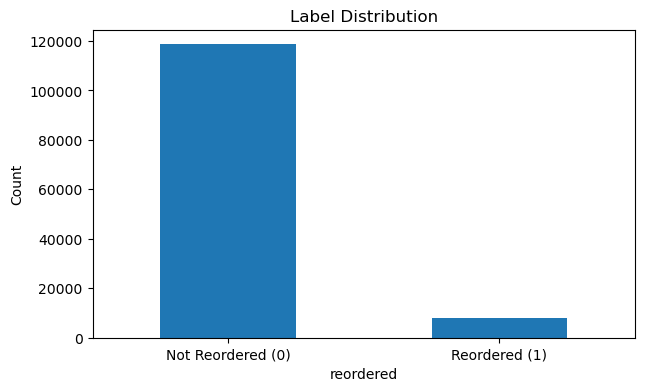

In [5]:
plt.figure(figsize=(7, 4))
df['reordered'].value_counts().sort_index().plot(kind='bar')
plt.xticks([0, 1], ['Not Reordered (0)', 'Reordered (1)'], rotation=0)
plt.title('Label Distribution')
plt.ylabel('Count')
plt.show()